<!--Copyright 2026 The HuggingFace Team. All rights reserved.

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
-->

# Fine-tuning LFM2-VL-450M on a tiny dataset (loss, before/after & generalization)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/lfm2_vl_finetuning.ipynb)

[LFM2-VL-450M](https://huggingface.co/LiquidAI/LFM2-VL-450M) is the smallest of Liquid AI's first vision-language foundation models — a **350M LFM2** language backbone + an **86M SigLIP2 NaFlex** vision encoder. At ~450M parameters it runs in a web browser (WebGPU) and is small enough to **LoRA fine-tune on a single small GPU (or even CPU) with fewer than 50 images**.

In this notebook we:

1. Load `LFM2-VL-450M` with `AutoModelForImageTextToText`.
2. Build a tiny but **diverse** synthetic dataset — **40 colors**, **12 shapes** (2D + pseudo-3D cube/sphere/cylinder/cone/pyramid), **five spatial relations** (inside / left / right / above / below).
3. Split it into a **training set** and a **held-out test set of *unseen combinations*** — every color, shape and relation is seen during training, but never in those arrangements. This separates *generalization* from mere memorization.
4. Fine-tune with **LoRA + TRL's `SFTTrainer`**, capturing the loss at every step.
5. **Visualize the loss curve** and **compare before/after predictions on the unseen test images**.

## 1. Setup

Install the dependencies. On Colab, restart the runtime if prompted after the install.

In [ ]:
%pip install -q -U transformers trl peft datasets accelerate pillow matplotlib torchvision

In [2]:
%matplotlib inline
import math
import random

import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw

from transformers import AutoModelForImageTextToText, AutoProcessor

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print('Using device:', device, '| dtype:', dtype)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu | dtype: torch.float32


## 2. Load the model and processor

In [3]:
model_id = 'LiquidAI/LFM2-VL-450M'
processor = AutoProcessor.from_pretrained(model_id)
if processor.tokenizer.pad_token_id is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

model = AutoModelForImageTextToText.from_pretrained(model_id, dtype=dtype).to(device)
print(f'Loaded {model_id} with {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters')

Loaded LiquidAI/LFM2-VL-450M with 451M parameters


## 3. Drawing the shapes

Every record is a dict `{image, question, answer}`:

- **`image`** + **`question`** are the model's **input**.
- **`answer`** is the **ground-truth label** — the text we train the model to produce. It is *not* an input.

We draw with Pillow (no download): **40 colors** and **12 shapes** — 2D (circle, square, triangle, diamond, pentagon, hexagon, star) and pseudo-3D (cube, sphere, cylinder, cone, pyramid).

In [4]:
COLORS = {
    'red': (220, 50, 50), 'green': (40, 170, 80), 'blue': (60, 90, 220), 'yellow': (240, 200, 40),
    'orange': (240, 140, 30), 'purple': (150, 60, 200), 'cyan': (40, 190, 200), 'pink': (240, 120, 180),
    'magenta': (200, 40, 160), 'lime': (140, 210, 40), 'teal': (20, 140, 140), 'navy': (30, 40, 120),
    'maroon': (130, 30, 40), 'olive': (120, 120, 30), 'brown': (140, 80, 40), 'gold': (212, 175, 55),
    'salmon': (240, 130, 110), 'coral': (240, 110, 80), 'crimson': (200, 20, 60), 'indigo': (75, 0, 130),
    'violet': (180, 90, 220), 'turquoise': (50, 200, 170), 'tan': (190, 150, 100), 'khaki': (180, 170, 90),
    'plum': (160, 90, 150), 'orchid': (190, 90, 180), 'chocolate': (160, 90, 40), 'tomato': (240, 90, 60),
    'sienna': (140, 80, 50), 'slateblue': (95, 95, 205), 'steelblue': (70, 120, 170), 'skyblue': (95, 170, 220),
    'seagreen': (40, 140, 95), 'forestgreen': (30, 115, 50), 'hotpink': (240, 100, 170), 'deeppink': (220, 40, 120),
    'mustard': (210, 170, 40), 'mint': (90, 205, 150), 'lavender': (170, 150, 225), 'rose': (220, 90, 130),
}
SHAPES_2D = ['circle', 'square', 'triangle', 'diamond', 'pentagon', 'hexagon', 'star']
SHAPES_3D = ['cube', 'sphere', 'cylinder', 'cone', 'pyramid']
SHAPES = SHAPES_2D + SHAPES_3D
RELATIONS = ['inside', 'to the left of', 'to the right of', 'above', 'below']
print(len(COLORS), 'colors x', len(SHAPES), 'shapes x', len(RELATIONS), 'relations')


def shade(rgb, f):
    return tuple(max(0, min(255, int(c * f))) for c in rgb)


def ngon(n, cx, cy, r, rot=-math.pi / 2):
    return [(cx + r * math.cos(rot + 2 * math.pi * i / n), cy + r * math.sin(rot + 2 * math.pi * i / n))
            for i in range(n)]


def star_pts(cx, cy, r):
    pts = []
    for i in range(10):
        rad = r if i % 2 == 0 else r * 0.45
        ang = math.pi * i / 5 - math.pi / 2
        pts.append((cx + rad * math.cos(ang), cy + rad * math.sin(ang)))
    return pts


def draw_shape(draw, shape, color, cx, cy, r):
    rgb = COLORS[color]
    if shape == 'circle':
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == 'square':
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == 'triangle':
        draw.polygon([(cx, cy - r), (cx - r * 0.92, cy + r * 0.8), (cx + r * 0.92, cy + r * 0.8)], fill=rgb)
    elif shape == 'diamond':
        draw.polygon([(cx, cy - r), (cx + r, cy), (cx, cy + r), (cx - r, cy)], fill=rgb)
    elif shape == 'pentagon':
        draw.polygon(ngon(5, cx, cy, r), fill=rgb)
    elif shape == 'hexagon':
        draw.polygon(ngon(6, cx, cy, r), fill=rgb)
    elif shape == 'star':
        draw.polygon(star_pts(cx, cy, r), fill=rgb)
    elif shape == 'cube':
        draw.polygon([(cx - r, cy - r / 2), (cx, cy), (cx, cy + r), (cx - r, cy + r / 2)], fill=shade(rgb, 0.6))
        draw.polygon([(cx, cy), (cx + r, cy - r / 2), (cx + r, cy + r / 2), (cx, cy + r)], fill=shade(rgb, 0.85))
        draw.polygon([(cx, cy - r), (cx + r, cy - r / 2), (cx, cy), (cx - r, cy - r / 2)], fill=shade(rgb, 1.2))
    elif shape == 'sphere':
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=shade(rgb, 0.8))
        for i in range(7):
            t = i / 7
            rr = r * (1 - t) * 0.85
            ox, oy = cx - r * 0.28, cy - r * 0.28
            draw.ellipse([ox - rr, oy - rr, ox + rr, oy + rr], fill=shade(rgb, 0.8 + 0.55 * t))
    elif shape == 'cylinder':
        eh = r * 0.32
        draw.ellipse([cx - r, cy + r - eh, cx + r, cy + r + eh], fill=shade(rgb, 0.65))
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=shade(rgb, 0.85))
        draw.ellipse([cx - r, cy - r - eh, cx + r, cy - r + eh], fill=shade(rgb, 1.15))
    elif shape == 'cone':
        eh = r * 0.32
        draw.ellipse([cx - r, cy + r - eh, cx + r, cy + r + eh], fill=shade(rgb, 0.65))
        draw.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=shade(rgb, 0.95))
    elif shape == 'pyramid':
        apex, front = (cx, cy - r), (cx, cy + r)
        draw.polygon([apex, (cx - r, cy + r * 0.35), front], fill=shade(rgb, 0.7))
        draw.polygon([apex, front, (cx + r, cy + r * 0.35)], fill=shade(rgb, 1.0))
    else:
        raise ValueError(shape)

40 colors x 12 shapes x 5 relations


In [5]:
def canvas(size=256):
    return Image.new('RGB', (size, size), 'white')


def render_single(color, shape, size=256):
    img = canvas(size)
    draw_shape(ImageDraw.Draw(img), shape, color, size // 2, size // 2, size // 3)
    return img


def render_inside(c_out, s_out, c_in, s_in, size=256):
    img = canvas(size)
    d = ImageDraw.Draw(img)
    draw_shape(d, s_out, c_out, size // 2, size // 2, size // 2 - 14)
    draw_shape(d, s_in, c_in, size // 2, size // 2, size // 7)
    return img


def render_pair(c1, s1, c2, s2, axis, size=256):
    img = canvas(size)
    d = ImageDraw.Draw(img)
    r = size // 7
    if axis == 'h':
        draw_shape(d, s1, c1, size // 4, size // 2, r); draw_shape(d, s2, c2, 3 * size // 4, size // 2, r)
    else:
        draw_shape(d, s1, c1, size // 2, size // 4, r); draw_shape(d, s2, c2, size // 2, 3 * size // 4, r)
    return img


def render_relation(c1, s1, relation, c2, s2):
    # Renders the scene matching 'the c1 s1 is <relation> the c2 s2'.
    if relation == 'inside':
        return render_inside(c2, s2, c1, s1)
    if relation == 'to the left of':
        return render_pair(c1, s1, c2, s2, 'h')
    if relation == 'to the right of':
        return render_pair(c2, s2, c1, s1, 'h')
    if relation == 'above':
        return render_pair(c1, s1, c2, s2, 'v')
    return render_pair(c2, s2, c1, s1, 'v')  # below


Q_SINGLE = "What colored shape is in this image? Answer with '<color> <shape>'."
Q_SPATIAL = 'Where is the {a} located relative to the {b}? Describe the spatial relationship.'


def single_record(color, shape):
    return {'image': render_single(color, shape), 'question': Q_SINGLE,
            'answer': f'{color} {shape}', 'meta': ('single', color, shape)}


def spatial_record(c1, s1, relation, c2, s2):
    return {'image': render_relation(c1, s1, relation, c2, s2),
            'question': Q_SPATIAL.format(a=f'{c1} {s1}', b=f'{c2} {s2}'),
            'answer': f'the {c1} {s1} is {relation} the {c2} {s2}',
            'meta': ('spatial', c1, s1, relation, c2, s2)}

## 4. Train set + held-out test set (unseen combinations)

We build a **training set** of 40 images and a **test set of 16 images whose exact combinations never appear in training**. The test only uses colors, shapes and relations that *were* seen during training — so any success reflects **compositional generalization**, not memorization of specific images.

In [6]:
N_TRAIN, N_TEST = 40, 16
rng = random.Random(SEED)

# ---- training set ----
n_single = round(N_TRAIN * 0.4)
n_spatial = N_TRAIN - n_single
train_records = []
single_combos = [(c, s) for c in COLORS for s in SHAPES]
rng.shuffle(single_combos)
for c, s in single_combos[:n_single]:
    train_records.append(single_record(c, s))
for i in range(n_spatial):
    rel = RELATIONS[i % len(RELATIONS)]
    pool = SHAPES_2D if rel == 'inside' else SHAPES
    c1, c2 = rng.sample(list(COLORS), 2)
    s1, s2 = rng.sample(pool, 2)
    train_records.append(spatial_record(c1, s1, rel, c2, s2))
rng.shuffle(train_records)

# ---- gather what was SEEN in training ----
seen_singles = {(m[1], m[2]) for r in train_records if (m := r['meta'])[0] == 'single'}
seen_spatial = {m for r in train_records if (m := r['meta'])[0] == 'spatial'}
seen_colors, seen_shapes, seen_rels = set(), set(), set()
for r in train_records:
    m = r['meta']
    if m[0] == 'single':
        seen_colors.add(m[1]); seen_shapes.add(m[2])
    else:
        seen_colors.update([m[1], m[4]]); seen_shapes.update([m[2], m[5]]); seen_rels.add(m[3])
seen_colors, seen_shapes, seen_rels = sorted(seen_colors), sorted(seen_shapes), sorted(seen_rels)

# ---- held-out test set: NOVEL combinations of SEEN tokens ----
trng = random.Random(SEED + 1)
test_records, used = [], set()
while sum(r['meta'][0] == 'single' for r in test_records) < round(N_TEST * 0.4):
    combo = (trng.choice(seen_colors), trng.choice(seen_shapes))
    if combo in seen_singles or combo in used:
        continue
    used.add(combo); test_records.append(single_record(*combo))
while len(test_records) < N_TEST:
    rel = trng.choice(seen_rels)
    pool = [s for s in seen_shapes if s in SHAPES_2D] if rel == 'inside' else seen_shapes
    if len(pool) < 2:
        continue
    c1, c2 = trng.sample(seen_colors, 2)
    s1, s2 = trng.sample(pool, 2)
    tup = ('spatial', c1, s1, rel, c2, s2)
    if tup in seen_spatial or tup in used:
        continue
    used.add(tup); test_records.append(spatial_record(c1, s1, rel, c2, s2))
trng.shuffle(test_records)

# sanity check: no test combination leaks into training
leak = sum(((r['meta'][1], r['meta'][2]) in seen_singles) if r['meta'][0] == 'single'
           else (r['meta'] in seen_spatial) for r in test_records)
print(f'train={len(train_records)}  test={len(test_records)}  leaked test combos={leak}')
print(f'seen during training: {len(seen_colors)} colors, {len(seen_shapes)} shapes, {len(seen_rels)} relations')

train_dataset = [{'messages': [
    {'role': 'user', 'content': [{'type': 'image', 'image': r['image']}, {'type': 'text', 'text': r['question']}]},
    {'role': 'assistant', 'content': [{'type': 'text', 'text': r['answer']}]},
]} for r in train_records]

train=40  test=16  leaked test combos=0
seen during training: 31 colors, 12 shapes, 5 relations


A peek at the **held-out test** images (these exact combinations are never trained on):

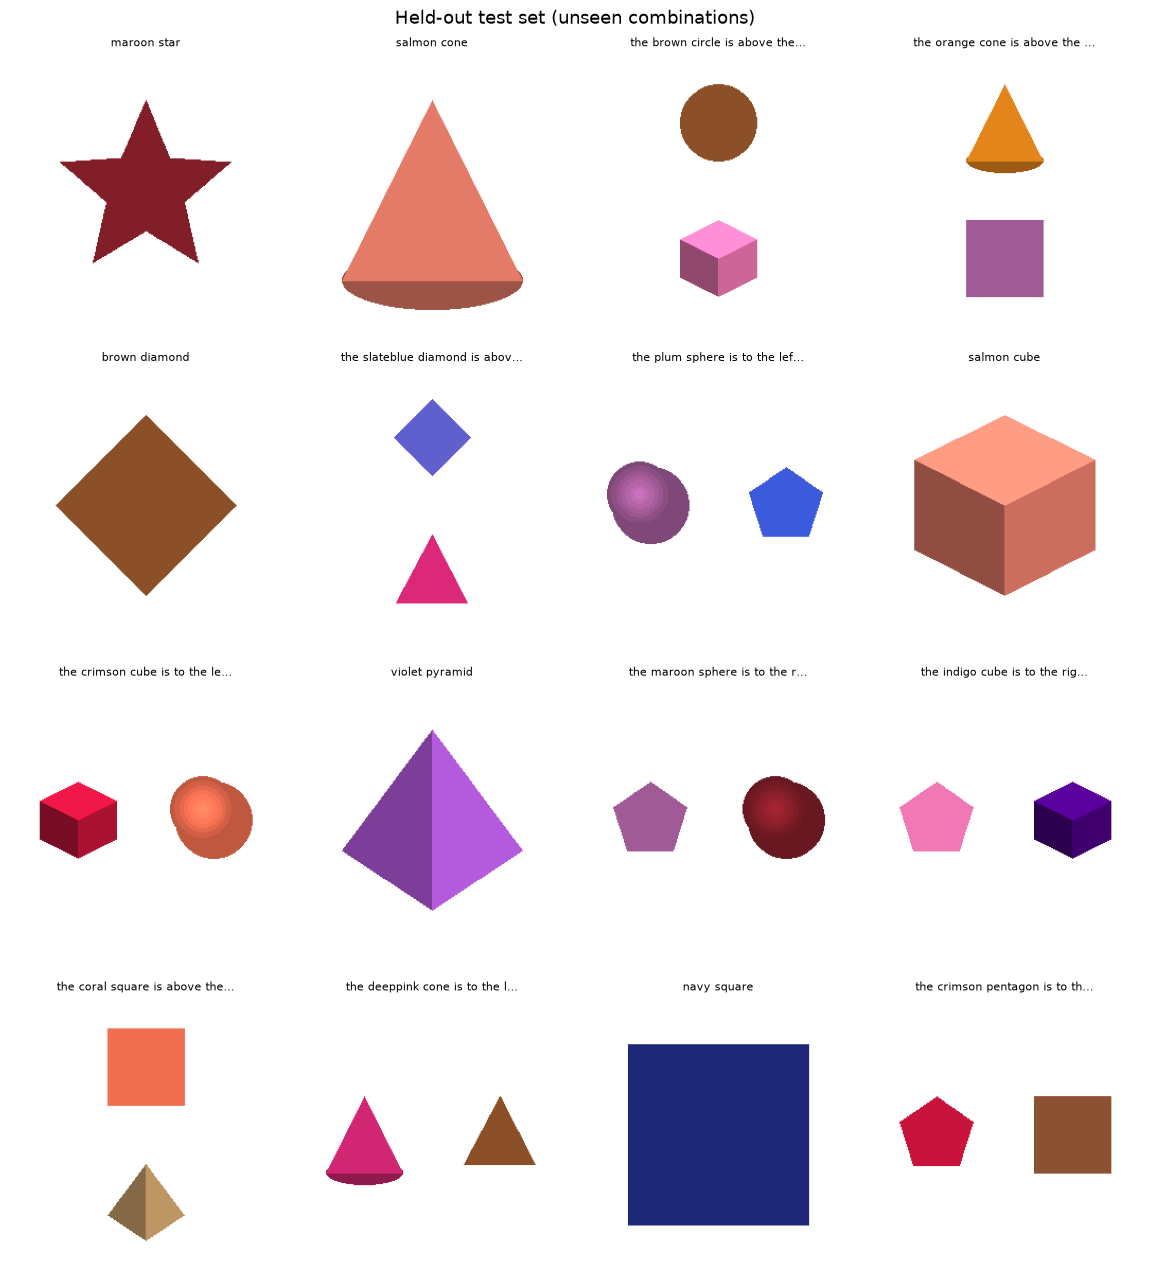

In [7]:
def clip(text, n=38):
    return text if len(text) <= n else text[:n - 1] + '\u2026'


cols = 4
rows = (len(test_records) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2.9 * cols, 3.3 * rows))
for ax, rec in zip(axes.flat, test_records):
    ax.imshow(rec['image']); ax.set_title(clip(rec['answer'], 30), fontsize=8); ax.axis('off')
for ax in axes.flat[len(test_records):]:
    ax.axis('off')
fig.suptitle('Held-out test set (unseen combinations)', fontsize=13)
plt.tight_layout(); plt.show()

## 5. Inference helper + scoring

In [8]:
@torch.no_grad()
def predict(model, record, max_new_tokens=28):
    conversation = [{'role': 'user', 'content': [
        {'type': 'image', 'image': record['image']},
        {'type': 'text', 'text': record['question']},
    ]}]
    inputs = processor.apply_chat_template(
        conversation, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors='pt',
    ).to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return processor.decode(out[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()


STOP = {'a', 'an', 'the', 'to', 'of', 'is', 'there'}


def normalize(text):
    return [w for w in text.lower().replace(',', ' ').replace('.', ' ').split() if w not in STOP]


def is_correct(pred, target):
    t = normalize(target)
    return normalize(pred)[:len(t)] == t


def accuracy(model, recs):
    preds = [predict(model, r) for r in recs]
    acc = sum(is_correct(p, r['answer']) for p, r in zip(preds, recs)) / len(recs)
    return preds, acc

## 6. Baseline on the held-out test set (before fine-tuning)

In [9]:
model.eval()
before_preds, before_acc = accuracy(model, test_records)
for rec, pred in zip(test_records, before_preds):
    print(f"gt={rec['answer'][:46]:<46} before={pred!r}")
print(f'\nbaseline test accuracy: {before_acc:.0%}')

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


gt=maroon star                                    before='The image contains a red star.'
gt=salmon cone                                    before='The image contains a red cone.'
gt=the brown circle is above the pink cube        before='The brown circle is located above and to the left of the pink cube. The spatial relationship shows that the circle is positioned higher and to the'
gt=the orange cone is above the plum square       before='The orange cone is positioned above and slightly to the left of the plum square. The spatial relationship is such that the cone is closer to the'
gt=brown diamond                                  before='brown diamond'
gt=the slateblue diamond is above the deeppink tr before='The slateblue diamond is located to the left of the deeppink triangle. The spatial relationship shows that the slateblue diamond'
gt=the plum sphere is to the left of the blue pen before='The plum sphere is located to the left of the blue pentagon. The sphere is smaller in size 

## 7. LoRA fine-tuning with TRL `SFTTrainer`

LoRA adapters on the attention + MLP projections, trained only on the **training set**. A `TrainerCallback` records the loss/token-accuracy each step. The collator masks **pad** and **`<image>`** tokens so loss is computed only on the answer text.

In [10]:
from peft import LoraConfig
from transformers import TrainerCallback
from trl import SFTConfig, SFTTrainer

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj', 'gate_proj', 'up_proj', 'down_proj'],
    task_type='CAUSAL_LM',
)
pad_token_id = processor.tokenizer.pad_token_id
image_token_id = processor.image_token_id


def collate_fn(examples):
    batch = processor.apply_chat_template(
        [ex['messages'] for ex in examples],
        add_generation_prompt=False, tokenize=True,
        return_dict=True, return_tensors='pt', padding=True,
    )
    labels = batch['input_ids'].clone()
    labels[labels == pad_token_id] = -100
    labels[labels == image_token_id] = -100
    batch['labels'] = labels
    return batch


class LossHistory(TrainerCallback):
    def __init__(self):
        self.steps, self.loss, self.acc = [], [], []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self.steps.append(state.global_step); self.loss.append(logs['loss'])
            self.acc.append(logs.get('mean_token_accuracy'))


history = LossHistory()

In [11]:
sft_config = SFTConfig(
    output_dir='./lfm2-vl-450m-lora',
    num_train_epochs=12,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    max_length=1024,
    logging_steps=1,
    bf16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
    remove_unused_columns=False,
    dataset_kwargs={'skip_prepare_dataset': True},
)
trainer = SFTTrainer(
    model=model, args=sft_config, train_dataset=train_dataset,
    data_collator=collate_fn, peft_config=peft_config,
    processing_class=processor.tokenizer, callbacks=[history],
)
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 7, 'bos_token_id': 1, 'pad_token_id': 0}.


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Step,Training Loss
1,7.731786
2,6.123552
3,7.537162
4,6.190156
5,6.330216
6,5.336946
7,4.892562
8,4.480247
9,3.930898
10,4.674678


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


...

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in LiquidAI/LFM2-VL-450M - will assume that the vocabulary was not modified.
  warnings.warn(


TrainOutput(global_step=480, training_loss=0.42695553847200546, metrics={'train_runtime': 1282.7808, 'train_samples_per_second': 0.374, 'train_steps_per_second': 0.374, 'total_flos': 114334483599360.0, 'train_loss': 0.42695553847200546})

## 8. Training loss curve

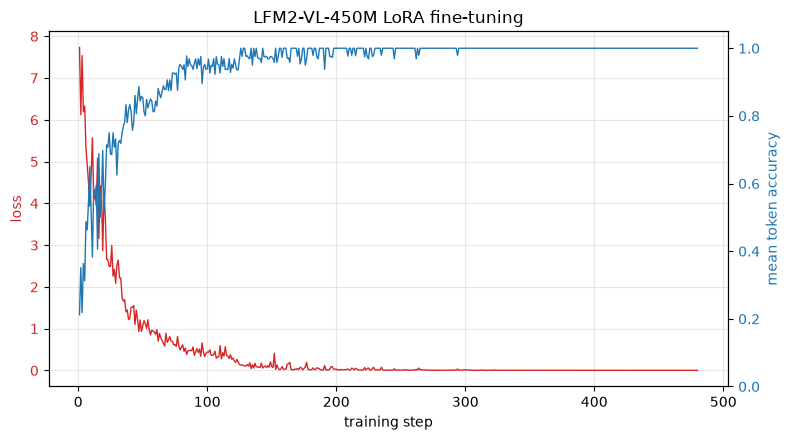

In [12]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(history.steps, history.loss, color='tab:red', lw=1, label='loss')
ax1.set_xlabel('training step'); ax1.set_ylabel('loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red'); ax1.grid(alpha=0.3)
if any(a is not None for a in history.acc):
    ax2 = ax1.twinx()
    ax2.plot(history.steps, history.acc, color='tab:blue', lw=1, label='token accuracy')
    ax2.set_ylabel('mean token accuracy', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue'); ax2.set_ylim(0, 1.05)
plt.title('LFM2-VL-450M LoRA fine-tuning'); fig.tight_layout(); plt.show()

## 9. After fine-tuning: memorization vs. generalization

We report accuracy on the **training set** (how well it memorized what it saw) and on the **held-out test set** (how well it generalizes to *unseen* combinations).

In [13]:
trainer.model.eval()
_, train_acc = accuracy(trainer.model, train_records)
after_preds, after_acc = accuracy(trainer.model, test_records)
for rec, pred in zip(test_records, after_preds):
    mark = 'OK' if is_correct(pred, rec['answer']) else '  '
    print(f"[{mark}] gt={rec['answer'][:42]:<42} after={pred!r}")
print(f'\ntrain-set accuracy (memorization): {train_acc:.0%}')
print(f'held-out test accuracy (before -> after generalization): {before_acc:.0%} -> {after_acc:.0%}')

[  ] gt=maroon star                                after='deeppink star'
[OK] gt=salmon cone                                after='salmon cone'
[OK] gt=the brown circle is above the pink cube    after='the brown circle is above the pink cube'
[OK] gt=the orange cone is above the plum square   after='the orange cone is above the plum square'
[OK] gt=brown diamond                              after='brown diamond'
[OK] gt=the slateblue diamond is above the deeppin after='the slateblue diamond is above the deeppink triangle'
[OK] gt=the plum sphere is to the left of the blue after='the plum sphere is to the left of the blue pentagon'
[OK] gt=salmon cube                                after='salmon cube'
[OK] gt=the crimson cube is to the left of the cor after='the crimson cube is to the left of the coral sphere'
[OK] gt=violet pyramid                             after='violet pyramid'
[OK] gt=the maroon sphere is to the right of the p after='the maroon sphere is to the right of the plum p

## 10. Before vs. after on the held-out test set

Each panel shows an **unseen** test image with its **ground-truth answer (gt)** and the model's prediction **before** (red if wrong) and **after** (green if correct) fine-tuning. The model's input is the image **plus the question** — only the answers are shown here.

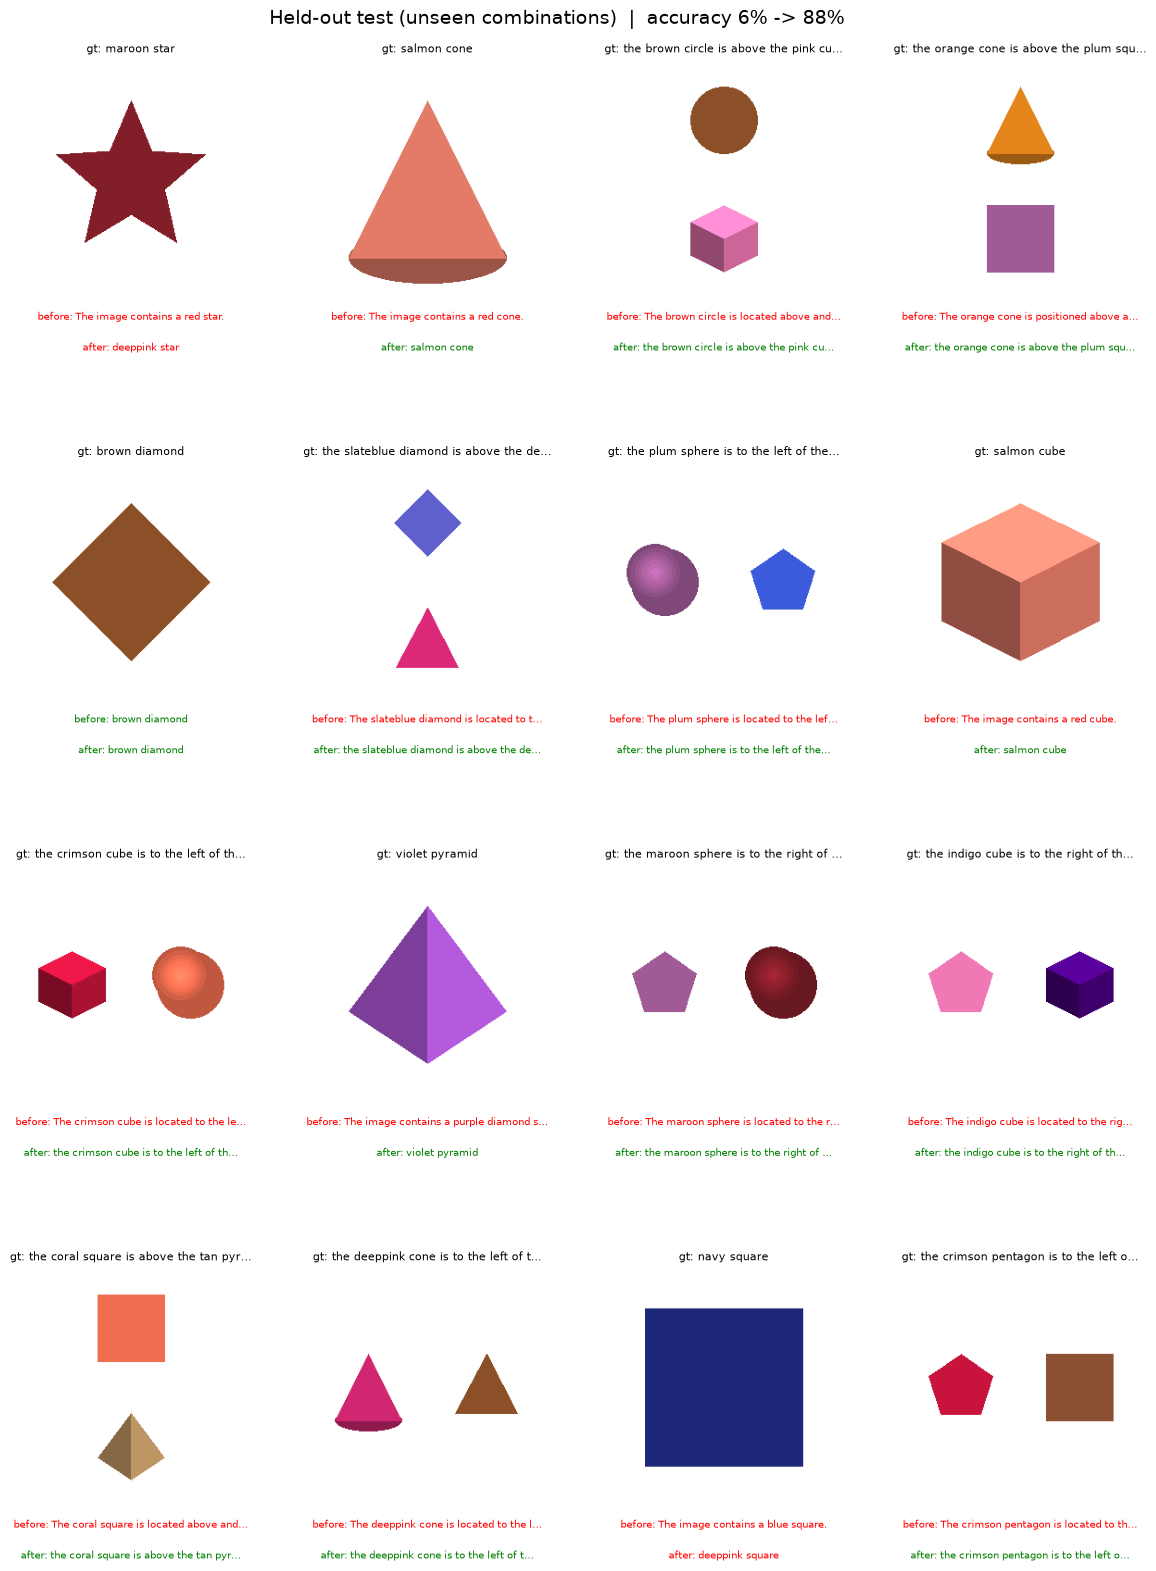

In [14]:
cols = 4
rows = (len(test_records) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.7 * cols, 4.3 * rows))
for ax, rec, before, after in zip(axes.flat, test_records, before_preds, after_preds):
    ax.imshow(rec['image']); ax.axis('off')
    b_color = 'green' if is_correct(before, rec['answer']) else 'red'
    a_color = 'green' if is_correct(after, rec['answer']) else 'red'
    ax.set_title(f"gt: {clip(rec['answer'], 38)}", fontsize=8)
    ax.text(0.5, -0.06, f'before: {clip(before, 38)}', color=b_color, fontsize=7.5,
            ha='center', va='top', transform=ax.transAxes)
    ax.text(0.5, -0.19, f'after: {clip(after, 38)}', color=a_color, fontsize=7.5,
            ha='center', va='top', transform=ax.transAxes)
for ax in axes.flat[len(test_records):]:
    ax.axis('off')
fig.suptitle(f'Held-out test (unseen combinations)  |  accuracy {before_acc:.0%} -> {after_acc:.0%}', fontsize=14)
plt.subplots_adjust(hspace=0.7, wspace=0.15, top=0.95)
plt.show()

## 11. Weight distribution: before vs. after

Because we used **LoRA**, the base weights are frozen — the model's change lives entirely in the adapter. For each adapted linear layer the effective update is

$$\Delta W = \frac{\alpha}{r}\, B A,$$

so the *after* weight is `W + ΔW`. Below we measure the **relative update** $\lVert\Delta W\rVert_F / \lVert W\rVert_F$ for every adapted layer and see **where** the model changed (which projections, vision vs. language, by depth) and **how much** the overall weight distribution moved.

In [15]:
import re
import numpy as np

stats, samp_before, samp_after = [], [], []
rng_np = np.random.default_rng(0)
for name, module in trainer.model.named_modules():
    lora_a = getattr(module, 'lora_A', None)
    if lora_a is None or 'default' not in lora_a:
        continue
    A = module.lora_A['default'].weight.detach().float()
    B = module.lora_B['default'].weight.detach().float()
    scaling = module.scaling['default']
    W = module.base_layer.weight.detach().float()
    dW = scaling * (B @ A)
    rel = (dW.norm() / W.norm()).item()
    comp = 'vision' if 'vision_tower' in name else 'language'
    depth = int(m.group(1)) if (m := re.search(r'layers\.(\d+)\.', name)) else -1
    stats.append({'name': name, 'proj': name.split('.')[-1], 'comp': comp, 'depth': depth, 'rel': rel})
    # sample weight values for the global before/after histogram
    flat = W.flatten()
    idx = rng_np.integers(0, flat.numel(), size=min(1500, flat.numel()))
    samp_before.append(flat[idx].numpy())
    samp_after.append((flat[idx] + dW.flatten()[idx]).numpy())

rels = np.array([s['rel'] for s in stats])
print(f'{len(stats)} LoRA-adapted layers')
print(f'relative update ||dW||/||W||:  median {np.median(rels):.3f}  mean {rels.mean():.3f}  max {rels.max():.3f}')
print('\nby projection type:')
for proj in sorted({s['proj'] for s in stats}):
    rs = [s['rel'] for s in stats if s['proj'] == proj]
    print(f'  {proj:10s} n={len(rs):2d}  mean rel={np.mean(rs):.3f}')
print('\nby component:')
for comp in ['vision', 'language']:
    rs = [s['rel'] for s in stats if s['comp'] == comp]
    if rs:
        print(f'  {comp:10s} n={len(rs):2d}  mean rel={np.mean(rs):.3f}')
print('\nmost-updated layers:')
for s in sorted(stats, key=lambda s: s['rel'], reverse=True)[:5]:
    print(f"  {s['rel']:.3f}  {s['name'].replace('base_model.model.model.', '')}")

82 LoRA-adapted layers
relative update ||dW||/||W||:  median 0.026  mean 0.029  max 0.177

by projection type:
  k_proj     n=18  mean rel=0.024
  out_proj   n=28  mean rel=0.037
  q_proj     n=18  mean rel=0.024
  v_proj     n=18  mean rel=0.029

by component:
  vision     n=48  mean rel=0.024
  language   n=34  mean rel=0.037

most-updated layers:
  0.177  language_model.layers.15.conv.out_proj
  0.068  language_model.layers.14.self_attn.v_proj
  0.067  language_model.layers.14.self_attn.out_proj
  0.052  language_model.layers.13.conv.out_proj
  0.045  language_model.layers.12.self_attn.v_proj


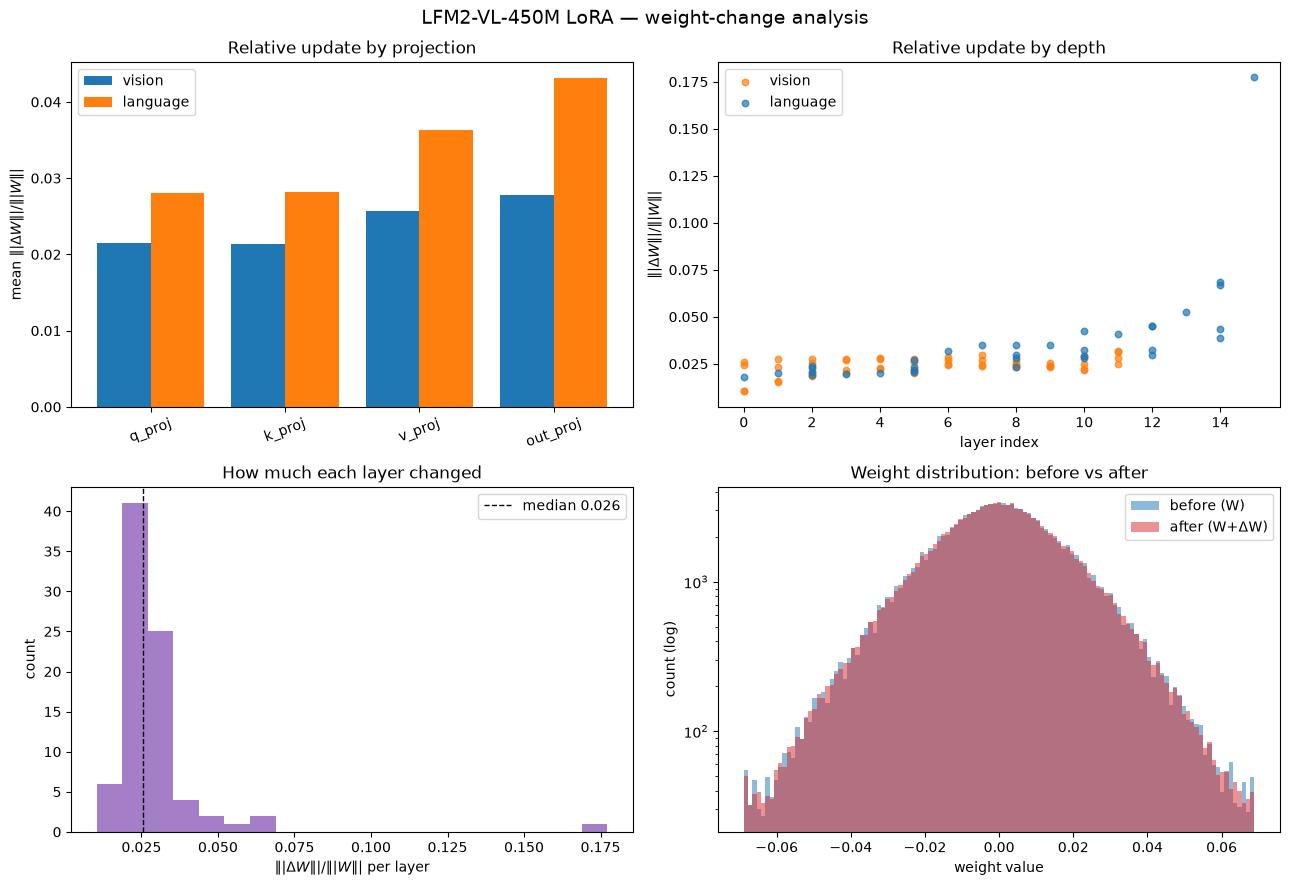

In [16]:
projs = [p for p in ['q_proj', 'k_proj', 'v_proj', 'out_proj'] if any(s['proj'] == p for s in stats)]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) relative update by projection type, vision vs language
ax = axes[0, 0]
x = np.arange(len(projs))
for i, comp in enumerate(['vision', 'language']):
    vals = [np.mean([s['rel'] for s in stats if s['proj'] == p and s['comp'] == comp] or [0]) for p in projs]
    ax.bar(x + (i - 0.5) * 0.4, vals, width=0.4, label=comp)
ax.set_xticks(x); ax.set_xticklabels(projs, rotation=20)
ax.set_ylabel(r'mean $\||\Delta W\|| / \||W\||$'); ax.set_title('Relative update by projection'); ax.legend()

# (b) relative update vs depth
ax = axes[0, 1]
for comp, color in [('vision', 'tab:orange'), ('language', 'tab:blue')]:
    pts = [(s['depth'], s['rel']) for s in stats if s['comp'] == comp and s['depth'] >= 0]
    if pts:
        xs, ys = zip(*pts)
        ax.scatter(xs, ys, c=color, label=comp, alpha=0.7, s=22)
ax.set_xlabel('layer index'); ax.set_ylabel(r'$\||\Delta W\|| / \||W\||$')
ax.set_title('Relative update by depth'); ax.legend()

# (c) distribution of per-layer relative updates
ax = axes[1, 0]
ax.hist(rels, bins=20, color='tab:purple', alpha=0.85)
ax.axvline(np.median(rels), color='k', ls='--', lw=1, label=f'median {np.median(rels):.3f}')
ax.set_xlabel(r'$\||\Delta W\|| / \||W\||$ per layer'); ax.set_ylabel('count')
ax.set_title('How much each layer changed'); ax.legend()

# (d) weight-value distribution before vs after (sampled across all adapted layers)
ax = axes[1, 1]
before = np.concatenate(samp_before); after = np.concatenate(samp_after)
lim = np.percentile(np.abs(before), 99.5)
bins = np.linspace(-lim, lim, 120)
ax.hist(before, bins=bins, alpha=0.5, label='before (W)', color='tab:blue', log=True)
ax.hist(after, bins=bins, alpha=0.5, label='after (W+ΔW)', color='tab:red', log=True)
ax.set_xlabel('weight value'); ax.set_ylabel('count (log)')
ax.set_title('Weight distribution: before vs after'); ax.legend()

fig.suptitle('LFM2-VL-450M LoRA — weight-change analysis', fontsize=14)
plt.tight_layout(); plt.show()

## 12. Save and reload the adapter

In [17]:
trainer.save_model('./lfm2-vl-450m-lora')
processor.save_pretrained('./lfm2-vl-450m-lora')

# Reload later with:
# from peft import PeftModel
# base = AutoModelForImageTextToText.from_pretrained(model_id, dtype=dtype)
# tuned = PeftModel.from_pretrained(base, './lfm2-vl-450m-lora')
# tuned = tuned.merge_and_unload()  # optional: fold LoRA into the base weights
print('Saved adapter + processor to ./lfm2-vl-450m-lora')

Saved adapter + processor to ./lfm2-vl-450m-lora


/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in LiquidAI/LFM2-VL-450M - will assume that the vocabulary was not modified.
  warnings.warn(


## Notes & next steps

- The **train-set** accuracy measures memorization; the **held-out test** accuracy measures *generalization* to unseen color/shape/relation combinations. A gap between them is exactly the overfitting signal to watch.
- This is a tiny CPU-friendly demo. With a GPU you can raise the dataset size, epochs and image-token budget, and enlarge the held-out set for a tighter generalization estimate.
- Swap the synthetic data for your own images — keep the `{image, question, answer}` shape and the rest is unchanged. For a real Hub dataset, load a small slice with `datasets.load_dataset(name, split='train[:40]')` and map it into the same conversation format.

**References**: [Liquid AI blog](https://www.liquid.ai/blog/lfm2-vl-efficient-vision-language-models) · [LFM2-VL-450M model card](https://huggingface.co/LiquidAI/LFM2-VL-450M) · [LFM2-VL TRL guide](https://docs.liquid.ai/customization/finetuning-frameworks/trl)